In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 10)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
import scipy.constants as constants
from scipy import special
import scipy
import math
import referenceFrames as rf
from decimal import Decimal
from astropy.modeling import models, fitting

In [2]:
def sci_str(dec):
    dec = Decimal(str(dec))
    return ('{:.' + str(len(dec.normalize().as_tuple().digits) - 1) + 'E}').format(dec)

# Documentation

## Applicable documents

AD-1: PLATO Mission Requirements Document, D. Agnolon

AD-2: PLATO 01 R BOL, data package v1.4 (normal camera, beginning of life, required), Anko Börner 

AD-3: PLATO 02 R BOL, data package v1.4 (normal camera, end of life, required), Anko Börner

AD-5: PLATO 80 FCamB R EOL, data package v1.0 (fast camera, blue, end of life, required), Anko Börner 

AD-7: PLATO 81 FCamR R EOL, data package v1.0 (fast camera, red, end of life, required), Anko Börner AD-8: PLATO-DLR-PL-TN-003 Reference Photon Flux

AD-9: PLATO-DLR-PL-RP-001 Instrument Noise Budget

AD-10: PLATO-INAF-PL-RP-001, Telescope Optical Units Performance Analysis report, v2

AD-11: PLATO-DLR-PL-RP-004, Simulations nad Performance Estimations, v1

AD-12: PLATO-ESTEC-PL-RS-003, PLATO CCD requirements

AD-13: Modelling CTI in PLATO-like images, T. Prod’homme, T. Oosterbroek

AD-14: PLATO-OHV-PL-LI-0009, PLATO Instrument Coordinate Systems

AD-15: PLATO-KUL-PL-TN-0001, PlatoSim Reference Frames

AD-16: PLATO-OHB-PL-RS-005, N FEE User Requirements Document, v2

AD-17: CTI measurements, modelling, requirements, Anko Börner

AD-18: PLATO-DLR-PL-TN-016: Geometric Camera Model for PLATO TOU

AD-19: Photometry impacts of Brighter-Fatter Effect (BFE) and CCD  diffusion, Réza Samadi

AD-20: PLATO-KUL-PL-TN-0003: PLATO FEE readout modes for AIV, Pierre Royer & Ann Baeke

## Reference documents

RD-1: An analytical model of radiation-induced Charge Transfer Inefficiency for CCD detectors, Short, A. et al., MNRAS 420, 3078-3085, 2013

RD-2: Evidence for self-interaction of charge distribution in charge-coupled devices, Guyonnet, A. et al. A & A, 575, A41, 2015

# Wavelength range

* Minimum wavelength: req. 240 in [AD-2] - [AD-7]
* Maximum wavelength: req. 250 in [AD-2] - [AD-7]

In [3]:
minWavelength = 500      # Minimum wavelength [nm]
maxWavelength = 1000     # Maximum wavelength [nm]

print("Wavelength range for simulations:", minWavelength, " -", maxWavelength, "nm")

Wavelength range for simulations: 500  - 1000 nm


# Pixel size
Req. 630 in [AD-2] - [AD-7]

In [4]:
pixelSize = 18  # Pixel size [µm  / pixel]

print("Pixel size:", pixelSize, "micron / pixel")

Pixel size: 18 micron / pixel


# CCD Positions
* Number of rows: req. 610 in [AD-2] - AD-7
* Number of columns: req. 620 in [AD-2] - AD-7
* Butting distance: req. req. 285 in [AD-2] - [AD-7]

In [5]:
numRows = 4510
numColumns = 4510

buttingDistance = 2.6     # Butting distance [mm]
halfButtingDistance = buttingDistance / 2.0

deltaX = halfButtingDistance
deltaY = halfButtingDistance + numRows * pixelSize * (constants.micro / constants.milli)

rotationAngle = {"1": 0, "2": 90, "3": 180, "4": 270, "1F": 0, "2F": 90, "3F": 180, "4F": 270}

In [6]:
def printCCD(ccd):
    print("CCD", ccd, "has", numRows, "x", numColumns, "pixels, offset (" + str(deltaX) + " mm,", str(deltaY) + " mm) and a rotation angle of", str(rotationAngle[ccd]) + "°")

In [7]:
print("CCDs for the normal cameras:\n")

for ccd in ["1", "2", "3", "4"]:
    
    printCCD(ccd)

CCDs for the normal cameras:

CCD 1 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 0°
CCD 2 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 90°
CCD 3 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 180°
CCD 4 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 270°


In [8]:
print("CCDs for the fast cameras:\n")

for ccd in ["1F", "2F", "3F", "4F"]:
    
    printCCD(ccd) 

CCDs for the fast cameras:

CCD 1F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 0°
CCD 2F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 90°
CCD 3F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 180°
CCD 4F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 270°


# Mission duration
Req. MRD-SC-009 in [AD-1]

In [9]:
missionDuration = 6.5   # Mission duration [years]

print("Mission duration:", missionDuration, "years")

Mission duration: 6.5 years


# Exposure time
Req. 290 in [AD-2] - [AD-7]

In [10]:
exposureTimeNormal = 21     # Exposure time for the normal cameras [s]
exposureTimeFast = 2.3      # Exposure time for the fast cameras [s]

print("Exposure time (normal cameras):", exposureTimeNormal, "s")
print("Exposure time (fast cameras):", exposureTimeFast, "s")

Exposure time (normal cameras): 21 s
Exposure time (fast cameras): 2.3 s


# Reference wavelength
Req. 070 in [AD-2] - [AD-7]

In [11]:
refWavelength = 550     # Reference wavelength [nm]

print("Reference wavelength:", refWavelength, "nm")

Reference wavelength: 550 nm


# Reference photon flux

## Irradiance
* Irradiance at magnitude 0 for a G0V star at 6000K: Table 2-1 in [AD-8] and Table 4-1 in [AD-9]

In [12]:
# Wavelengths [nm]

wavelengthIrradiance = np.arange(400, 1150, 50)     # 400 - 1100 nm

# Irradiance [1e5 photons / cm^2 / s]

irradiances = np.array([3.45, 4.20, 4.72, 5.01, 5.11, 5.09, 4.96, 4.77, 4.55, 4.30, 4.04, 3.79, 3.55, 3.31, 3.09])

# Integrated over all wavelengths (400 - 1100 nm)

irradiance = np.sum(irradiances[2:-2]) * 1e5  # Irradiance [photons / cm^2 / s]

print("Irradiance calculated over wavelength range", wavelengthIrradiance[2], "-", wavelengthIrradiance[-3], "nm:")
print("Irradiance:", sci_str(irradiance), "photons / cm^2 / s")

Irradiance calculated over wavelength range 500 - 1000 nm:
Irradiance: 4.988999999999999E+6 photons / cm^2 / s


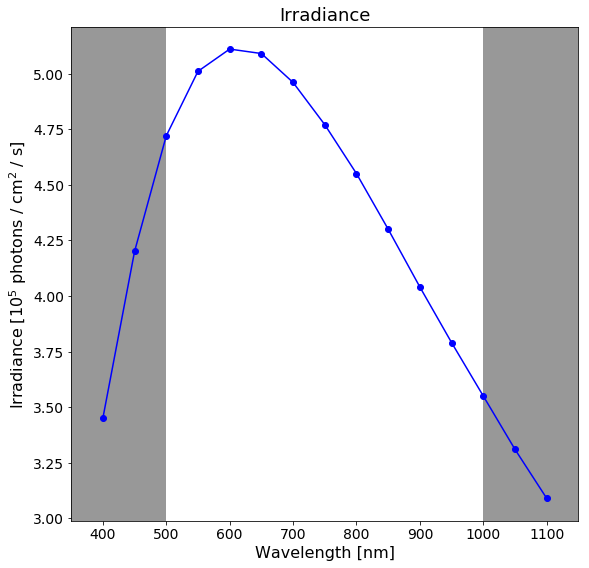

In [13]:
fig = plt.figure(figsize=(20, 20))
plt.subplot(221)
plt.plot(wavelengthIrradiance, irradiances, 'bo-')
plt.xlabel("Wavelength [nm]", fontsize = 16)
plt.ylabel(r'Irradiance [$10^5$ photons / cm$^2$ / s]', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.axvspan(350, 500, facecolor='0.2', alpha=0.5)
plt.axvspan(1000, 1150, facecolor='0.2', alpha=0.5)
plt.xlim([350, 1150])
plt.title("Irradiance",  fontsize = 18)
plt.show()

## Photon flux
* Reference photometric flux : req. 060 in [AD-2] - [AS-7]
* Reference wavelength: see above

In [14]:
# Reference photometric flux

photometricFlux = 3.6182e-12                                                            # [W / cm^2 / µm]
photometricFlux *= (pow(constants.centi, -2) * (constants.nano / constants.micron))     # [J / s / m^2 / nm]

# Energy of one photon at the reference wavelength

photonEnergy = constants.h * constants.c / refWavelength / constants.nano       # Photon energy [J]

photonFlux = photometricFlux / photonEnergy     # Photon flux [photons / s / m^2 / nm]

print("Photon flux:", sci_str(photonFlux), "photons / s / m^2 / nm")

Photon flux: 1.0017942476884453E+8 photons / s / m^2 / nm


# Throughput bandwidth

In [15]:
throughputBandwidth = irradiance / photonFlux / pow(constants.centi, 2)   # Throughput bandwidth [nm]

print("Throughput bandwidth:", throughputBandwidth, "nm")

Throughput bandwidth: 498.0064530727433 nm


# Cosmic hits
Req. 790 in [AD-2] - [AD-9]

In [16]:
cosmicHitRate = 10  # Cosmic hit rate [events / cm^2 / s]

print("Cosmic hit rate:", cosmicHitRate, "events / cm^2 / s")

Cosmic hit rate: 10 events / cm^2 / s


# Light collecting area
* Light collecting area: req. 410 in [AD-2] - [AD-7]
* Effective pupil diameter: req. 420 in [AD-2] - [AD-7]

In [17]:
lightCollectingArea = 113.1 # Light collecting area [cm^2]

print("Light collecting area:", lightCollectingArea, "cm^2")

effictivePupilSize = 12                 # Effective pupil diameter [cm]
print(constants.pi * pow(12 / 2, 2), "cm^2")

Light collecting area: 113.1 cm^2
113.09733552923255 cm^2


# Transmissivity of the optics
Req. 420 in [AD-2] - [AD-7]:
* optics_transmission_1.5pc_bol_cutoff_v6.txt
* optics_transmission_1.5pc_eol_cutoff_v6.txt

In [18]:
# Wavelengths [nm]

wavelengthOptics = np.arange(500, 1050, 50)     # 500 - 1000 nm

transmissivityOpticsBOL = np.array([0.7651, 0.7972, 0.8048, 0.8107, 0.8183, 0.8243, 0.8284, 0.8301, 0.8319, 0.8327, 0.8344])
transmissivityOpticsEOL = np.array([0.7379, 0.7719, 0.7835, 0.7918, 0.8018, 0.8076, 0.8125, 0.8142, 0.8158, 0.8175, 0.8183])

meanTransmissivityOpticsBOL = np.mean(transmissivityOpticsBOL)
meanTransmissivityOpticsEOL = np.mean(transmissivityOpticsEOL)

print("Transmissivity of the optics calculated over wavelength range", wavelengthOptics[0], "-", wavelengthOptics[-1], "nm:")
print("Transmissivity of the optics (BOL):", meanTransmissivityOpticsBOL)
print("Transmissivity of the optics (EOL):", meanTransmissivityOpticsEOL)

Transmissivity of the optics calculated over wavelength range 500 - 1000 nm:
Transmissivity of the optics (BOL): 0.8161727272727273
Transmissivity of the optics (EOL): 0.7975272727272728


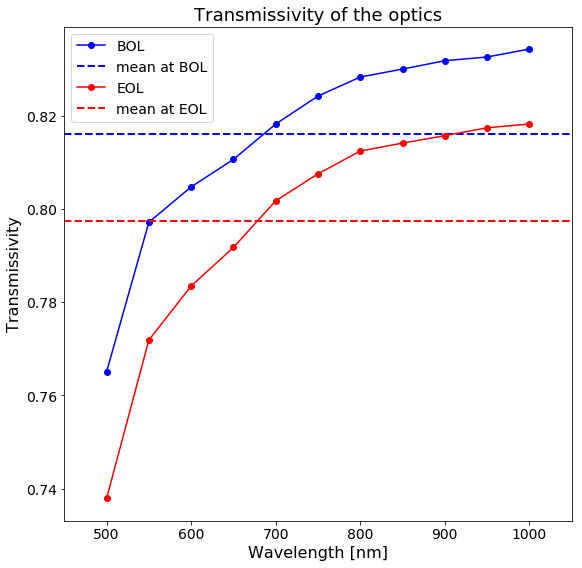

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(221)

plt.plot(wavelengthOptics, transmissivityOpticsBOL, "bo-", label = "BOL")
plt.axhline(y = meanTransmissivityOpticsBOL, color='b', linestyle='--', linewidth=2, label = "mean at BOL")
plt.plot(wavelengthOptics, transmissivityOpticsEOL, "ro-", label = "EOL")
plt.axhline(y = meanTransmissivityOpticsEOL, color='r', linestyle='--', linewidth=2, label = "mean at EOL")
plt.legend(prop={'size': 14})
plt.title("Transmissivity of the optics",  fontsize = 18)
plt.xlabel("Wavelength [nm]", fontsize = 16)
plt.ylabel("Transmissivity", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlim([450, 1050])
plt.show()

# Plate scale
* Pixel size: see above
* Plate scale [arcsec / pixel]: req. 440 in [AD-2] - [AD-7]

In [ ]:
plateScaleArcsec = 15   # Plate scale [arcsec / pixel]

plateScale =  plateScaleArcsec / pixelSize # Plate scale [arcsec / µm]

print("Plate scale:", plateScale, "arcsec / micron")

Plate scale: 0.8333333333333334 arcsec / micron


# Focal length
Req. 420 in [AD-2] - [AD-8]

The focal length, expressed in m, can be calculated as:

$$\rm{focal\,length [m]} = \frac{\rm pixel\,size}{\tan{\left( \frac{\rm plate\,scale}{2} \right)}}.$$

Alternatively, expressed in pixels:

$$\rm{focal\,length [pixels]} = \frac{1}{\tan{(\rm plate\,scale)}}$$

In [ ]:
pixelSizeMeter = pixelSize * constants.micro              # Pixel size [µm] -> [m]
plateScaleRadians = plateScaleArcsec * constants.arcsec   # Plate scale [arcsec] -> [radians]

focalLength = pixelSizeMeter / (math.tan(plateScaleRadians))    # Focal length [m]
focalLengthPixels = math.ceil(1 / math.tan(plateScaleRadians))  # Focal length [pixels]

print("Focal length:", focalLength, "m")
print("Focal length:", focalLengthPixels, "pixels")

Focal length: 0.24751776706018327 m
Focal length: 13751 pixels


# Field distortion

* Distorted ("real") and undistorted ("paraxial") pixel coordinates: PLATO_Field_Distortion.txt (Demetrio)
* Distortion model: Sect. 3.1 in [AD-18]
* Distortion at the edge of the FOV (18.8876°): req. 445 in [AD-2] - [AD-7]

In [ ]:
# Read the distortion file

xDeg, yDeg, radius, xReal, yReal, xParaxial, yParaxial, vignetted = \
    np.loadtxt("PLATO_Field_Distortion.txt", unpack=True)

# Real chief ray: [mm] -> [pixels]

xRealPixels = xReal /  (pixelSize / constants.milli * constants.micro)
yRealPixels = yReal / (pixelSize / constants.milli * constants.micro)

# Paraxial chief ray: [mm] -> [pixels]

xParaxialPixels = xParaxial / (pixelSize / constants.milli * constants.micro)
yParaxialPixels = yParaxial / (pixelSize / constants.milli * constants.micro)

In [ ]:
# Size of the FOV

fovDegrees = 18.8875
fovPixels = fovDegrees / plateScaleArcsec * constants.degree / constants.arcsec

focalLengthMm = focalLength / constants.milli

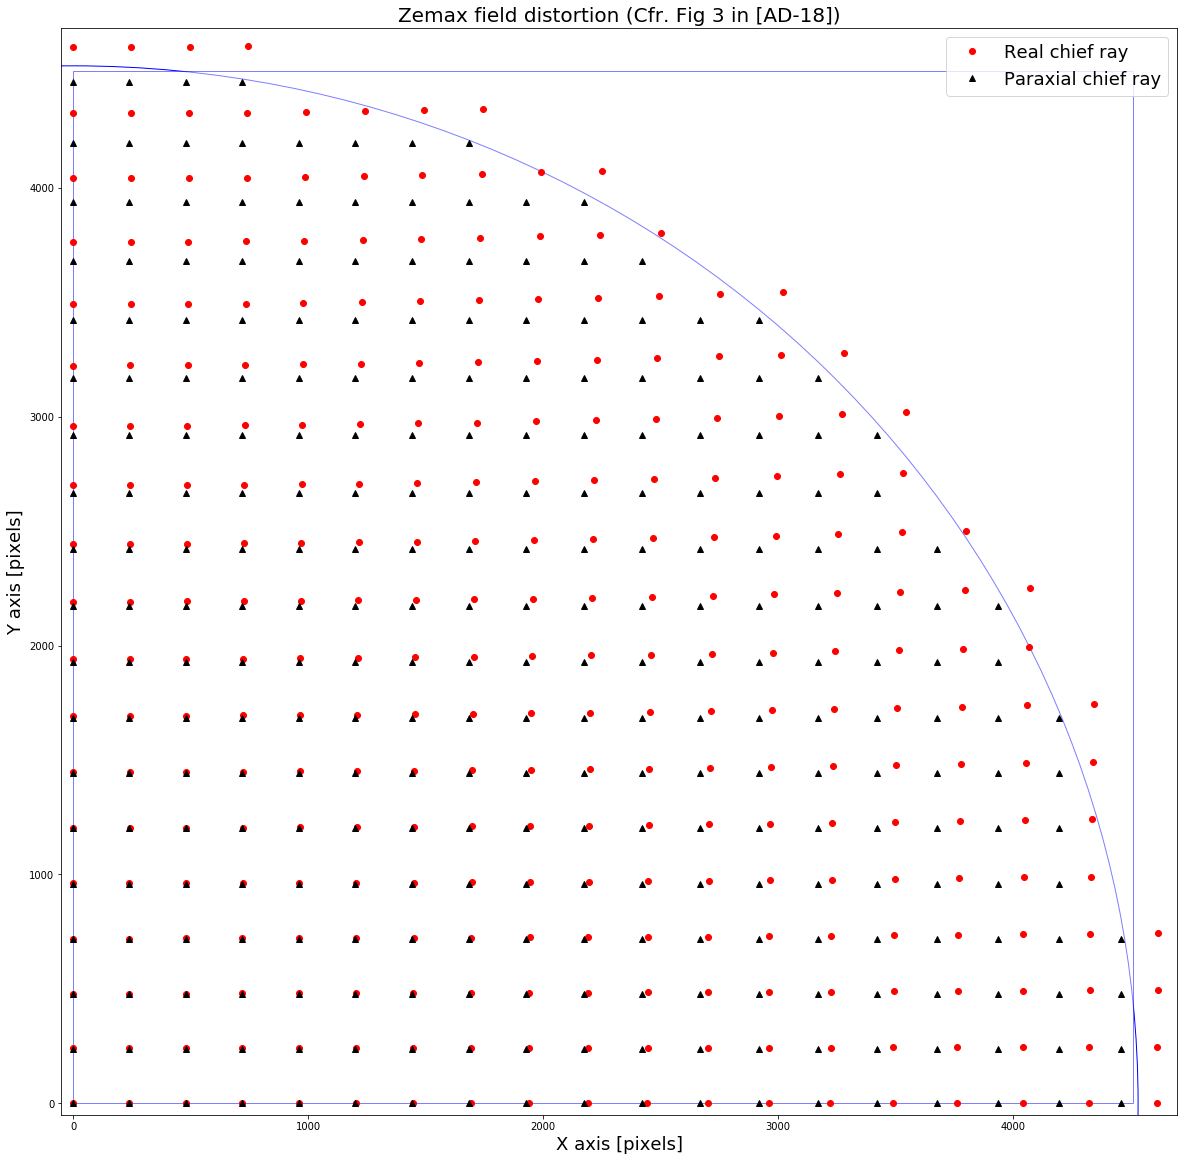

In [ ]:
# Re-shaping

xParaxialPixelsReshaped = xParaxialPixels.reshape(181, 181)
xRealPixelsReshaped = xRealPixels.reshape(181, 181)

yParaxialPixelsReshaped = yParaxialPixels.reshape(181, 181)
yRealPixelsReshaped = yRealPixels.reshape(181, 181)

# Visualise distortion in steps of 1° and only within the FOV (i.e. radius <= 18.8876°) 

step = 10

radiusParaxialReshaped = np.sqrt(np.power(xParaxialPixelsReshaped[::step,::step], 2) + np.power(yParaxialPixelsReshaped[::step,::step], 2))
fovSelection = radiusParaxialReshaped <= fovPixels

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(1, 1, 1)

plt.plot(xRealPixelsReshaped[::step,::step][fovSelection], yRealPixelsReshaped[::step,::step][fovSelection], "ro", label = "Real chief ray")
plt.plot(xParaxialPixelsReshaped[::step,::step][fovSelection], yParaxialPixelsReshaped[::step,::step][fovSelection], "k^", label = "Paraxial chief ray")

circ = plt.Circle((0,0), radius = fovPixels, color = "white")
ax.add_patch(circ)
circ.set_edgecolor("b")
circ.set_facecolor("w")

rect = plt.Rectangle((0, 0), 4510, 4510, 0.0, alpha = 0.5)
ax.add_patch(rect)
rect.set_edgecolor("b")
rect.set_facecolor("w")

plt.xlabel("X axis [pixels]", fontsize = 18)
plt.ylabel("Y axis [pixels]", fontsize = 18)
plt.legend(prop={'size': 18})
plt.xlim([-50, 4700])
plt.ylim([-50, 4700])

plt.title("Zemax field distortion (Cfr. Fig 3 in [AD-18])", fontsize = 20)

plt.show()

In [ ]:
# Field radius [pixels] of the undistorted and distorted positions

radiusPixelsUndistorted = np.sqrt(np.power(xParaxialPixels, 2) + np.power(yParaxialPixels, 2))
radiusPixelsDistorted = np.sqrt(np.power(xRealPixels, 2) + np.power(yRealPixels, 2))

# Field radius of the undistorted positions [degrees]

radiusDegUndistorted = np.zeros(len(radius))

for index in range(len(radius)):
    radiusDegUndistorted[index] = rf.gnomonicRadialDistanceFromOpticalAxis(xParaxial[index], yParaxial[index], focalLengthMm)

radiusDegUndistorted = np.rad2deg(radiusDegUndistorted)   # Conversion [radians] -> [degrees]

# Field radius of the distorted positions [degrees]

radiusDegDistorted = np.zeros(len(radius))

for index in range(len(radius)):
    radiusDegDistorted[index] = rf.gnomonicRadialDistanceFromOpticalAxis(xReal[index], yReal[index], focalLengthMm)

radiusDegDistorted = np.rad2deg(radiusDegDistorted)   # Conversion [radians] -> [degrees]

# Distortion

distortionX = xRealPixels - xParaxialPixels    # Distortion in the X-direction [pixels]
distortionY = yRealPixels - yParaxialPixels    # Distortion in the Y-direction [pixel]

distortion = np.sqrt(np.power(distortionX, 2) + np.power(distortionY, 2))   # Distortion in the radial direction (away from the optical axis)

## Undistorted -> distorted

Radial distortion model (pincushion/barrel distortion):

$$\rm{distortion} = r \cdot (k_1 \cdot r^2 + k_2 \cdot r^4 + k_3 \cdot r^6)$$

where the distortion is expressed in normalised pixels and $r$ is the __undistorted__ field radius, expressed in normalised pixels.

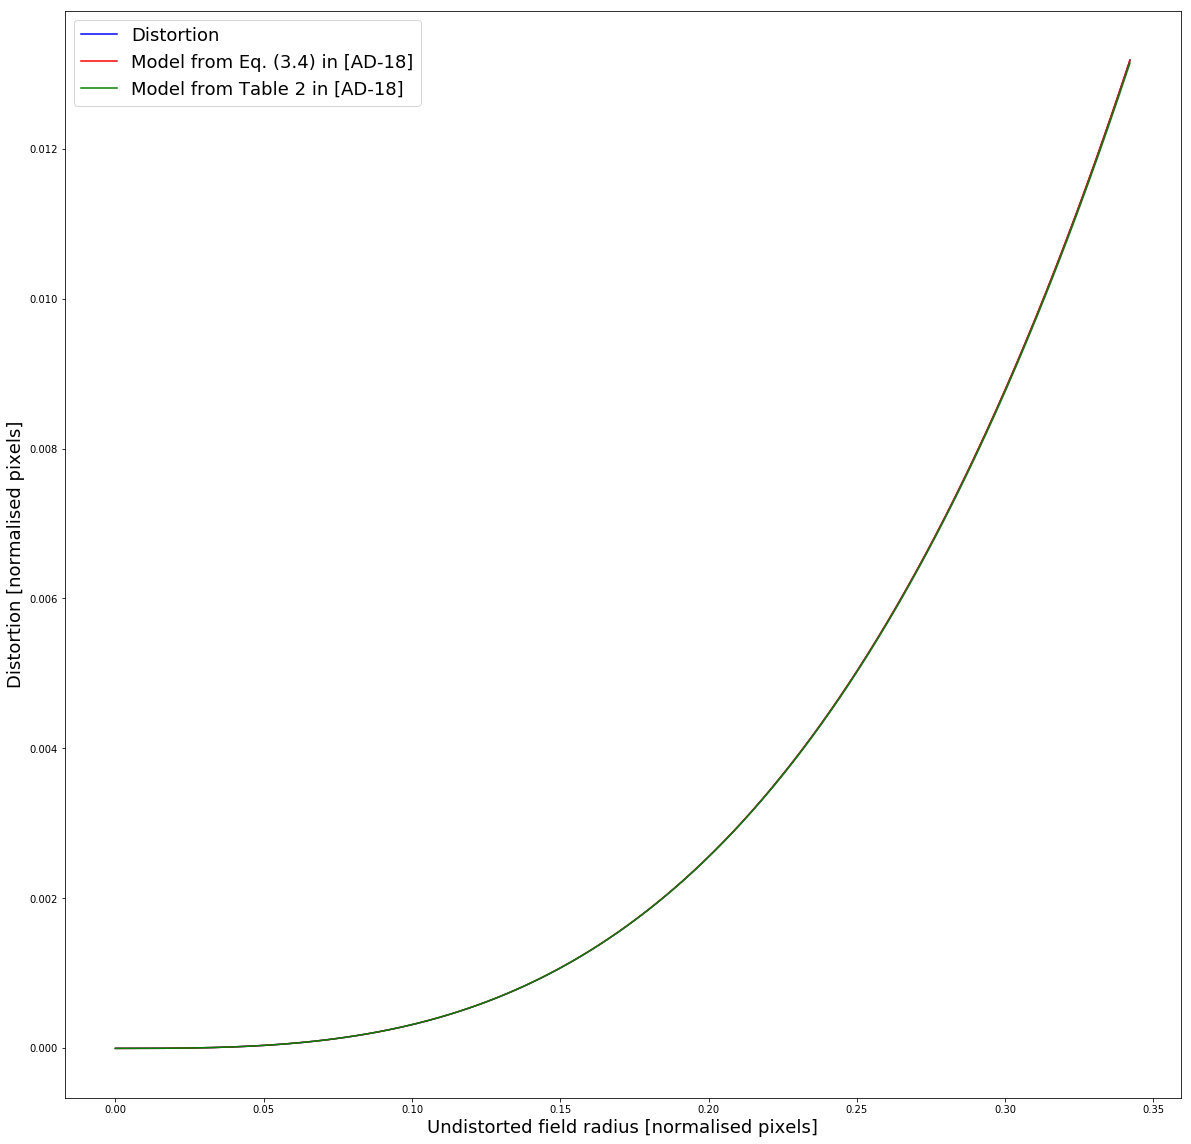

Fit parameters: undistorted -> distorted:
* k1: 0.3162572105771702
* k2: 0.06637321968802608
* k3: 0.372589221218671


In [ ]:
# Select undistorted positions within the FOV

fovSelectionU2D = (radiusDegUndistorted <= fovDegrees)

radiusPixelsU2D = radiusPixelsUndistorted[fovSelectionU2D]
distortionU2D = distortion[fovSelectionU2D]

# Sort by increasing radius

indices = np.argsort(radiusPixelsU2D)

radiusPixelsU2D = radiusPixelsU2D[indices]
distortionU2D = distortionU2D[indices]

# Normalisation: divide out the focal length

radiusPixelsU2D /= focalLengthPixels
distortionU2D /= focalLengthPixels

# Distortion model described in Eq. (3.4) in PLATO-DLR-PL-TN-016

p_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c4 = 0, c6 = 0)

p_init.c0.fixed = True
p_init.c1.fixed = True
p_init.c2.fixed = True
p_init.c4.fixed = True
p_init.c6.fixed = True

fit_p = fitting.LevMarLSQFitter()
p = fit_p(p_init, radiusPixelsU2D, distortionU2D)

# Model with parameters values taken from Table 2 in [AD-18]

pDenis_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c3 = 0.3160, c4 = 0, c5 = 0.0553, c6 = 0, c7 = 0.4177)

pDenis_init.c0.fixed = True
pDenis_init.c1.fixed = True
pDenis_init.c2.fixed = True
pDenis_init.c3.fixed = True
pDenis_init.c4.fixed = True
pDenis_init.c5.fixed = True
pDenis_init.c6.fixed = True
pDenis_init.c7.fixed = True

fit_pDenis = fitting.LevMarLSQFitter()
pDenis = fit_p(pDenis_init, radiusPixelsU2D, distortionU2D)

# Plotting

fig = plt.figure(figsize=(20,20))

plt.plot(radiusPixelsU2D, distortionU2D, "b", label = "Distortion")
plt.plot(radiusPixelsU2D, p(radiusPixelsU2D), "r-", label = "Model from Eq. (3.4) in [AD-18]")
plt.plot(radiusPixelsU2D, pDenis(radiusPixelsU2D), "g-", label = "Model from Table 2 in [AD-18]")
plt.xlabel("Undistorted field radius [normalised pixels]", fontsize = 18)
plt.ylabel("Distortion [normalised pixels]", fontsize = 18)
plt.legend(prop={'size': 18})

plt.show()

print("Fit parameters: undistorted -> distorted:")
print("* k1:", p.c3.value)
print("* k2:", p.c5.value)
print("* k3:", p.c7.value)

In [ ]:
distortionAtEdge = p(fovPixels / focalLengthPixels)
distortionAtEdgeDenis = pDenis(fovPixels / focalLengthPixels)

print("Distortion at the edge of the FOV:", str(distortionAtEdge / fovPixels * focalLengthPixels * 100.0) + "%")
print("Distortion at the edge of the FOV (Denis):", str(distortionAtEdgeDenis / fovPixels * focalLengthPixels * 100.0) + "%")
print("Compare with req. 445: 3.84%")

Distortion at the edge of the FOV: 3.5629043751752283%
Distortion at the edge of the FOV (Denis): 3.5528219738192632%
Compare with req. 445: 3.84%


## Distorted -> undistorted

Radial distortion model (pincushion/barrel distortion):

$$\rm{distortion} = r \cdot (k_1 \cdot r^2 + k_2 \cdot r^4 + k_3 \cdot r^6)$$

where the distortion is expressed in normalised pixels and $r$ is the __distorted__ field radius, expressed in normalised pixels.

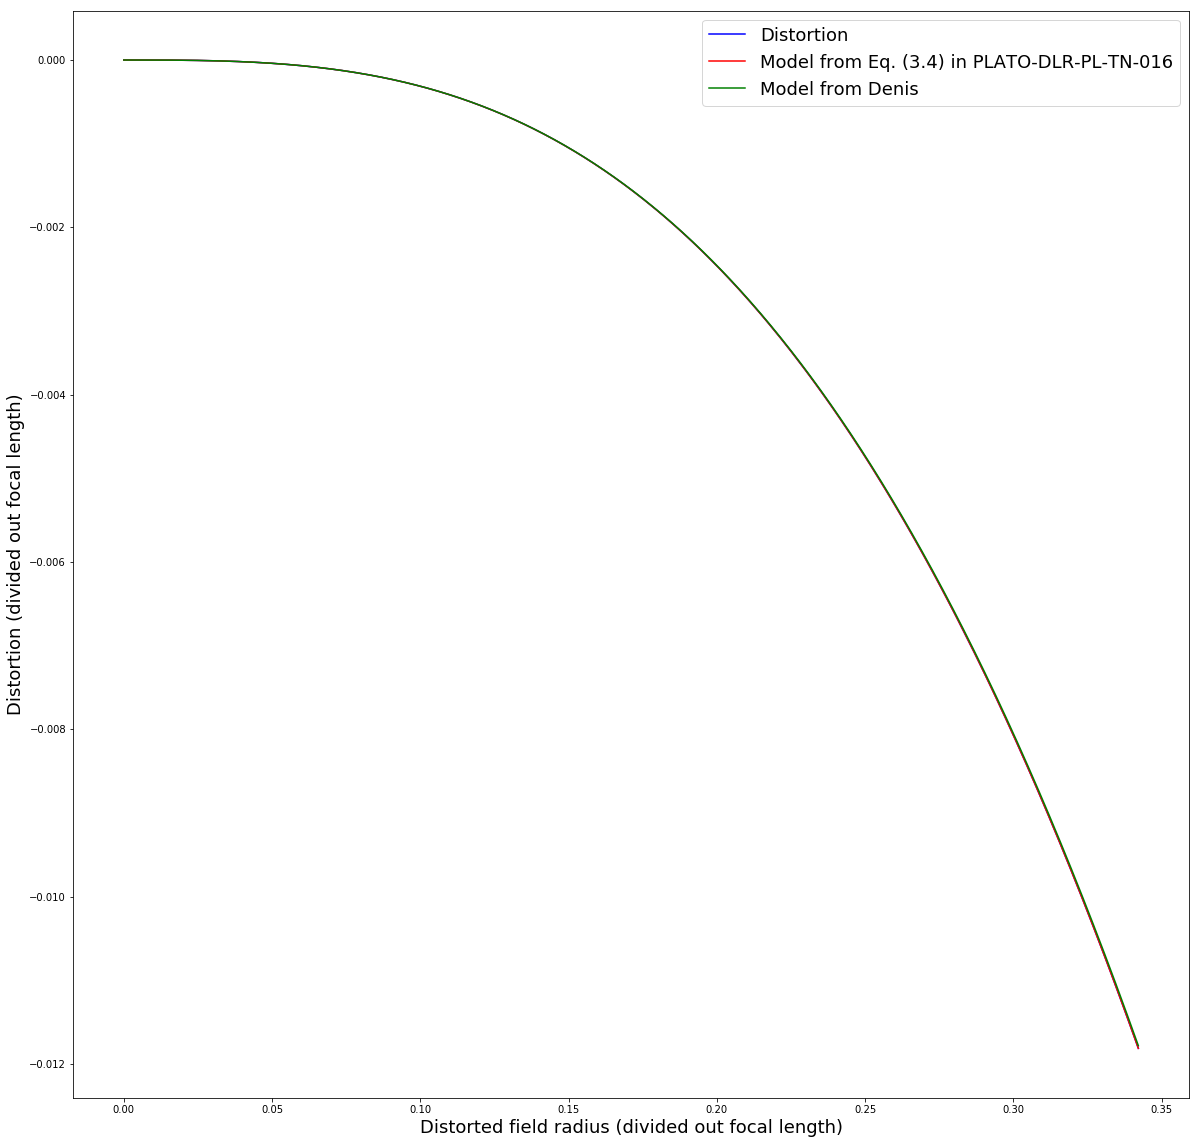

Fit parameters: distorted -> undistorted:
* k1: -0.31582682263330175
* k2: 0.2149591994669812
* k3: -0.32359675151229866


In [ ]:
# Select undistorted positions within the FOV

fovSelectionD2U = (radiusDegDistorted <= fovDegrees)

radiusPixelsD2U = radiusPixelsDistorted[fovSelectionD2U]
distortionD2U = distortion[fovSelectionD2U]

# Sort by increasing radius

indices = np.argsort(radiusPixelsD2U)

radiusPixelsD2U = radiusPixelsD2U[indices]
distortionD2U = distortionD2U[indices]

radiusPixelsD2U /= focalLengthPixels
distortionD2U *= (-1)
distortionD2U /= focalLengthPixels

# Distortion model described in Eq. (3.4) in [AD-18]

p_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c4 = 0, c6 = 0)

p_init.c0.fixed = True
p_init.c1.fixed = True
p_init.c2.fixed = True
p_init.c4.fixed = True
p_init.c6.fixed = True

fit_p = fitting.LevMarLSQFitter()
p = fit_p(p_init, radiusPixelsD2U, distortionD2U)

pDenis_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c3 = -0.3155, c4 = 0, c5 = 0.2245, c6 = 0, c7 = 0-0.3706)

pDenis_init.c0.fixed = True
pDenis_init.c1.fixed = True
pDenis_init.c2.fixed = True
pDenis_init.c3.fixed = True
pDenis_init.c4.fixed = True
pDenis_init.c5.fixed = True
pDenis_init.c6.fixed = True
pDenis_init.c7.fixed = True

fit_pDenis = fitting.LevMarLSQFitter()
pDenis = fit_p(pDenis_init, radiusPixelsD2U, distortionD2U)


# Plotting

fig = plt.figure(figsize=(20,20))

plt.plot(radiusPixelsD2U, distortionD2U, "b", label = "Distortion")
plt.plot(radiusPixelsD2U, p(radiusPixelsD2U), "r-", label = "Model from Eq. (3.4) in PLATO-DLR-PL-TN-016")
plt.plot(radiusPixelsD2U, pDenis(radiusPixelsD2U), "g-", label = "Model from Denis")
plt.xlabel("Distorted field radius (divided out focal length)", fontsize = 18)
plt.ylabel("Distortion (divided out focal length)", fontsize = 18)
plt.legend(prop={'size': 18})

plt.show()

print("Fit parameters: distorted -> undistorted:")
print("* k1:", p.c3.value)
print("* k2:", p.c5.value)
print("* k3:", p.c7.value)

# Gaussian PSF
* Mask size: req. 450 in [AD-2] - [AD-7]
* Percentage of enclosed energy: req. 460 in [AD-2] - [AD-7]

In [ ]:
maskSize = 1.0#2.5          # Square mask of 2.5 x 2.5 pixel
ensquaredEnergy = 0.32#0.9   # 90% of the PSF's energy should be ensquared by the mask

In [ ]:
# See https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule

n = scipy.special.erfinv(math.sqrt(ensquaredEnergy)) * math.sqrt(2)
sigmaPsf = (maskSize / 2.0) / n

print("Sigma for the Gaussian PSF:", sigmaPsf, "pixels")

# math.erf(n / math.sqrt(2))**2 # Enclosed energy

Sigma for the Gaussian PSF: 0.6395253379543886 pixels


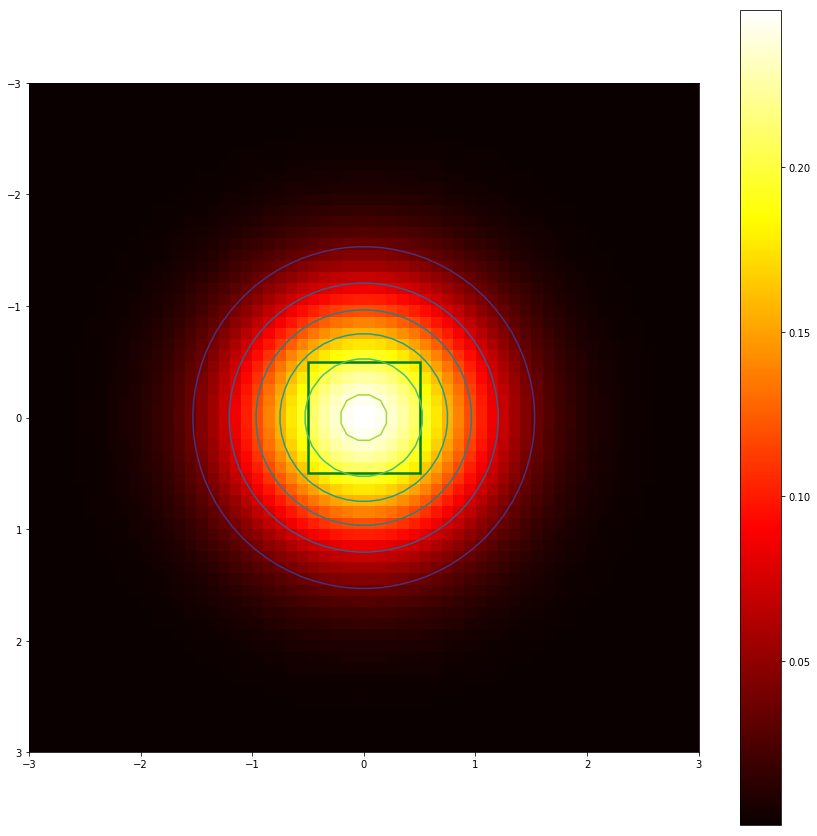

In [ ]:
N = 60
X = np.linspace(-3, 3, N)
Y = np.linspace(-3, 3, N)
X, Y = np.meshgrid(X, Y)


centroid = np.array([0., 0.])
covarianceMatrix = np.array([[ sigmaPsf , 0.0], [0.0,  sigmaPsf]])

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, centroid, covarianceMatrix):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = centroid.shape[0]
    detCovarianceMatrix = np.linalg.det(covarianceMatrix)
    inverseCovarianceMatrix = np.linalg.inv(covarianceMatrix)
    N = np.sqrt((2*np.pi)**n * detCovarianceMatrix)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-centroid, inverseCovarianceMatrix, pos-centroid)

    return np.exp(-fac / 2) / N

Z = multivariate_gaussian(pos, centroid, covarianceMatrix)

fig,ax = plt.subplots(figsize=(15,15))
plt.imshow(Z, extent=[-3,3, -3,3], cmap=cm.hot, interpolation="nearest")
plt.gca().invert_yaxis()
plt.colorbar()
rect = patches.Rectangle((-1.25 + 1.5/2.0,-1.25 + 1.5/2.0),1,1,linewidth=2.5,edgecolor='g',facecolor='none')
#rect = patches.Rectangle((-1.25,-1.25),2.5,2.5,linewidth=2.5,edgecolor='g',facecolor='none')
ax.add_patch(rect)
plt.contour(Z, extent=[-3,3, -3,3])
plt.show()

# Charge diffusion & jitter smoothing

In [ ]:
chargeDiffusionStrength = 0.2    # [pixels]
jitterSmoothingStrength = 0.5    # [sub-pixels]

print("Width of the Gaussian diffusion kernel (for charge diffusion):", chargeDiffusionStrength, "pixels")
print("Jitter smoothing corresponds to applying a Gaussian diffusion kernel with a width of", jitterSmoothingStrength, "sub-pixels")

Width of the Gaussian diffusion kernel (for charge diffusion): 0.2 pixels
Jitter smoothing corresponds to applying a Gaussian diffusion kernel with a width of 0.5 sub-pixels


# Nominal operating temperature of the FEE
[AD-16]

In [ ]:
nominalTemperatureFEE = -63     # Nominal operating temperature of the FEE [°C]

print("Nominal operating temperature of the FEE:", nominalTemperatureFEE, "°C")

Nominal operating temperature of the FEE: -63 °C


# Readout noise FEE

Req. 860 in [AD-2] - [AD-7]

In [ ]:
readoutNoiseNormalBOL = 37.0   # Readout noise for the normal cameras [e- / pixel]
readoutNoiseNormalEOL = 32.0   # Readout noise for the normal cameras [e- / pixel]
#readoutNoiseFast = 122      # Readout noise for the fast cameras [e- / pixel]

print("Readout noise for the FEE (normal cameras, BOL):", readoutNoiseNormalBOL, "e- / pixel")
print("Readout noise for the FEE (normal cameras, EOL):", readoutNoiseNormalEOL, "e- / pixel")
#print("Readout noise for the FEE (fast cameras):", readoutNoiseFast, "e- / pixel")

Readout noise for the FEE (normal cameras, BOL): 37.0 e- / pixel
Readout noise for the FEE (normal cameras, EOL): 32.0 e- / pixel


# Gain
* Total gain: req. 880 in [AD-2] - [AD-7]
* Temperature stability of the FEE gain: req. 840 in [AD-2] - [AD-6]
* CCD gain: req. 680 in [AD-2] - [AD7]
* Temperature stability of the CCD gain: Sect. 5.2.2.5 in [AD-9]

In [ ]:
# Total gain [e- / ADU]

totalGainNormal = 20    # Total gain for the normal cameras
totalGainFast = 61      # Total gain for the fast cameras

# CCD gain

gainCCD = 1.8               # CCD gain [µV / e-]
gainStabilityCCD = 0.004   # Temperature stability of the CCD gain [µV / e- / K]

# FEE gain

gainNormalFEE = 1 / gainCCD / totalGainNormal   # FEE gain for the normal camera [ADU / µV]
gainFastFEE = 1 / gainCCD / totalGainFast       # FEE gain for the fast camera [ADU / µV]
gainStabilityFEE = 300e-6                       # Temperature stability of the FEE gain [ADU / µV / K]

print("CCD gain:", gainCCD, "µV / e- (temperature stability:", gainStabilityCCD ,"µV / e- / K)\n")

print("FEE gain (normal cameras):", gainNormalFEE, "ADU / µV (temperature stability:", gainStabilityFEE ,"ADU / µV / K)")
print("FEE gain (fast cameras):", gainFastFEE, "ADU / µV (temperature stability:", gainStabilityFEE ,"ADU / µV / K)")

CCD gain: 1.8 µV / e- (temperature stability: 0.004 µV / e- / K)

FEE gain (normal cameras): 0.02777777777777778 ADU / µV (temperature stability: 0.0003 ADU / µV / K)
FEE gain (fast cameras): 0.009107468123861567 ADU / µV (temperature stability: 0.0003 ADU / µV / K)


# Electronic offset
* Electronic offset: no value available
* Temperature stability of the electronic offset: req. 850 in [AD-2] - [AD-7]

In [ ]:
electronicOffset = None     # Electronic offset [ADU / pixel]

electronicOffsetStabilityNormal = 1     # Temperature stability of the electronic offset for normal cameras [ADU / K]
electronicOffsetStabilityFast = 10      # Temperature stability of the electronic offset for fast cameras [ADU / K]

print("Electronic offset (normal cameras):", electronicOffset, "ADU / pixel (temperature stability:", electronicOffsetStabilityNormal ,"ADU / pixel / K)")
print("Electronic offset (fast cameras):", electronicOffset, "ADU / pixel (temperature stability:", electronicOffsetStabilityFast ,"ADU / pixel / K)")

Electronic offset (normal cameras): None ADU / pixel (temperature stability: 1 ADU / pixel / K)
Electronic offset (fast cameras): None ADU / pixel (temperature stability: 10 ADU / pixel / K)


# Nominal operating temperature of the CCD
Req. CC-GEN-008 in [AD-16]

In [ ]:
nominalTemperatureCCD = -70    # Nominal operating temperature of the CCD [°C]

print("Nominal operating temperature of the CCD:", nominalTemperatureCCD, "°C")

Nominal operating temperature of the CCD: -70 °C


# Quantum efficiency
* QE: req. 650 in [AD-2] - [AD-7]: ccd_qe_min_bol.txt
* Angle dependency: req. 660 in [AD-2] - [AD-7]

In [ ]:
wavelengthQE = np.arange(400, 1150, 50)
qe = np.array([0.375, 0.575, 0.737, 0.807, 0.877, 0.867, 0.858, 0.757, 0.655, 0.485, 0.314, 0.165, 0.062, 0.0, 0.0])

meanQE = np.mean(qe[2:-2])  # Take the average between 500 and 1000 nm

#refAngleQE = 45     # Reference angle [°]
#refValueQE = 0.925  # Value of the angle dependency of the QE at the reference angle

In [ ]:
expectedEfficiencyQE = np.mean(qe[2:-2])  # Take the average between 500 and 1000 n

print("Quantum efficiency calculated over wavelength range", wavelengthQE[2], "-", wavelengthQE[-3], "nm:")
print("Expected efficiency caused by QE:", expectedEfficiencyQE)

Quantum efficiency calculated over wavelength range 500 - 1000 nm:
Expected efficiency caused by QE: 0.5985454545454546


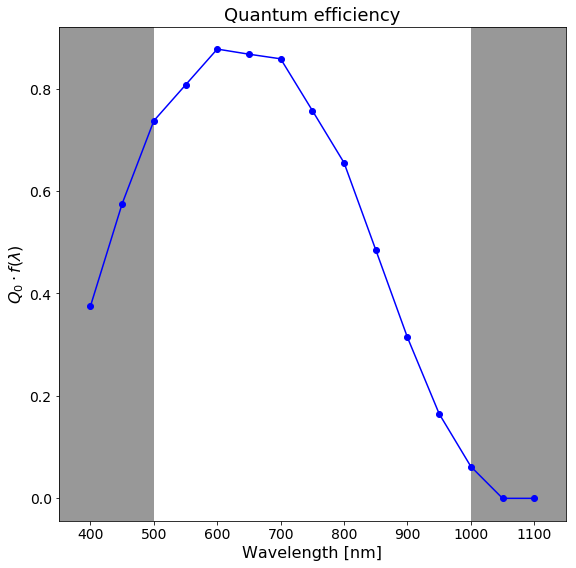

In [ ]:
fig = plt.figure(figsize=(20, 20))
plt.subplot(221)
plt.plot(wavelengthQE, qe, 'bo-')
plt.xlabel("Wavelength [nm]", fontsize = 16)
plt.ylabel(r'$Q_0 \cdot f(\lambda )$', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.axvspan(350, 500, facecolor='0.2', alpha=0.5)
plt.axvspan(1000, 1150, facecolor='0.2', alpha=0.5)
plt.xlim([350, 1150])
plt.title("Quantum efficiency", fontsize = 18)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

In [ ]:
expectedEfficiencyAngleDependencyQE = 1.01
print("Expected efficiency caused by the angle dependence of QE:", expectedEfficiencyAngleDependencyQE)

Expected efficiency caused by the angle dependence of QE: 1.01


# Full-well saturation (blooming)
Req. 640 in [AD-2] - [AD-7]

In [ ]:
fullWellSaturation = 900000 # Full-well saturation limit [e- / pixel]

print("Full-well saturation:", fullWellSaturation, "e- / pixel")

Full-well saturation: 900000 e- / pixel


# Digital saturation
Req. 870 in [AD-2] - [AD-7]

In [ ]:
def getDigitalSaturation(numBits):
    
    """
    Converts the number of ADC quantisation bits  into the digital
    saturation limit, expressed in [ADU / pixel].
    
    INPUT:
        - numBits: Number of ADC quantisation bits.
        
    OUTPUT: Digital saturation limit [ADU / pixel].
    """
    
    return int(math.pow(2, numBits) - 1)

In [ ]:
quantisationNormal = 16   # ADC quantisation for normal cameras [bits]
quantisationFast = 14     # ADC quantisation for fast cameras [bits]

digitalSaturationNormal = getDigitalSaturation(quantisationNormal)   # Digital-saturation limit for normal cameras [ADU / pixel]
digitalSaturationFast = getDigitalSaturation(quantisationFast)       # Digital-saturation limit for fast cameras [ADU / pixel]

print("Digital saturation (normal cameras):", digitalSaturationNormal, "ADU / pixel")
print("Digital saturation (fast cameras):", digitalSaturationFast, "ADU / pixel")

Digital saturation (normal cameras): 65535 ADU / pixel
Digital saturation (fast cameras): 16383 ADU / pixel


# Readout noise CCD
Req. 780 in [AD-2] - [AD-7]

In [ ]:
readoutNoiseBOL = 38.7  # Readout noise at BOL [e-]
readoutNoiseEOL = 44.3  # Readout noise at EOL [e-]

print("Readout noise for the CCD (BOL):", readoutNoiseBOL, "e-")
print("Readout noise for the CCD (EOL):", readoutNoiseEOL, "e-")

Readout noise for the CCD (BOL): 38.7 e-
Readout noise for the CCD (EOL): 44.3 e-


# Readout time
* Exposure time: see above
* Cadence: req. 300 in [AD-2] - [AD-7]
* Transfer times: [AD-20]

In [ ]:
"""
cadenceNormal = 25      # Cademce for the normal cameras [s]
cadenceFast = 2.5       # Cadence for the fast cameras[s]

readoutTimeNormal = cadenceNormal - exposureTimeNormal   # Readout time for the normal cameras [s]
readoutTimeFast = cadenceFast - exposureTimeFast   # Readout time for the fast cameras [s]

print("Readout time (normal cameras):", readoutTimeNormal, "s")
print("Readout time (fast cameras):", readoutTimeFast, "s")
"""

'\ncadenceNormal = 25      # Cademce for the normal cameras [s]\ncadenceFast = 2.5       # Cadence for the fast cameras[s]\n\nreadoutTimeNormal = cadenceNormal - exposureTimeNormal   # Readout time for the normal cameras [s]\nreadoutTimeFast = cadenceFast - exposureTimeFast   # Readout time for the fast cameras [s]\n\nprint("Readout time (normal cameras):", readoutTimeNormal, "s")\nprint("Readout time (fast cameras):", readoutTimeFast, "s")\n'

In [ ]:
serialTransferTime = 340        # Serial transfer time [ns]
parallelTransferTime = 110        # Parallel transfer time[µs]
parallelTransferTimeFast = 90     # Parallel transfer time fast [µs]

print("Time needed to shift the content of the readout register over one pixel (towards the output node):", serialTransferTime, "ns")
print("Time to shift the charges one row down in case the readout register will be read out:", parallelTransferTime, "µs")
print("Time to shift the charges one row down in case the readout register will not be read out:", parallelTransferTimeFast, "µs")

Time needed to shift the content of the readout register over one pixel (towards the output node): 340 ns
Time to shift the charges one row down in case the readout register will be read out: 110 µs
Time to shift the charges one row down in case the readout register will not be read out: 90 µs


# Flatfield
Req. 730 in [AD-2] - [AD-7]

In [ ]:
FlatfieldNoiseRMS = 0.010

print("Flatfield noise RMS (local PRNU):", FlatfieldNoiseRMS)

Flatfield noise RMS (local PRNU): 0.01


# Vignetting
Req. 520 in [AD-2] - [AD-7]

The efficiency caused by natural vignetting can be modelled as

$$E_{\rm vig.}(i,j) = \cos^2{(\theta(i,j))}.$$

In [ ]:
efficiencyVignetting = np.zeros((numRows, numColumns))
expectedEfficiencyVignetting = 0

for row in range(numRows):
    
    yFP = row * pixelSize * constants.micro / constants.milli + halfButtingDistance
    
    for column in range(numColumns):
        
        xFP = column * pixelSize * constants.micro / constants.milli + halfButtingDistance
        
        angularDistance = rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, focalLength / constants.milli)# Radians
        
        g = math.pow(np.cos(angularDistance), 2)
        
        efficiencyVignetting[row][column] = g
        expectedEfficiencyVignetting += g

expectedEfficiencyVignetting /= (numRows * numColumns)

print("Expected efficiency caused by vignetting:", expectedEfficiencyVignetting)

print("Reason that this value deviates from the expected value of 0.945:")
print("- mechanical vignetting is not included")
print("- the model for the natural vignetting is merely an approximation")

Expected efficiency caused by vignetting: 0.9317996251966464
Reason that this value deviates from the expected value of 0.945:
- mechanical vignetting is not included
- the model for the natural vignetting is merely an approximation


In [ ]:
expectedEfficiencyVignetting = 0.904

print("Expected efficiency caused by vignetting:", expectedEfficiencyVignetting)

Expected efficiency caused by vignetting: 0.904


In [ ]:
fig,ax = plt.subplots(figsize=(15,15))
plt.imshow(efficiencyVignetting, cmap=cm.hot, interpolation="nearest")
plt.gca().invert_yaxis()
plt.colorbar()
plt.contour(efficiencyVignetting)
plt.title("Vignetting", fontsize = 18)
plt.show()

In [ ]:
fieldRadiusVignetting = np.arange(0, 19.0)
fieldRadiusVignetting = np.append(fieldRadiusVignetting, 18.8875)

naturalVignetting = np.array([0.00, 0.03, 0.12, 0.27, 0.49, 0.76, 1.09, 1.49, 1.94, 2.45, 3.02, 3.64, 4.32, 5.06, 5.85, 6.70, 7.60, 8.55, 9.55, 10.48])
mechanicalVignetting = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.04, 0.38, 0.97, 2.06, 3.62])

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(221)

plt.plot(fieldRadiusVignetting, naturalVignetting, "bo", label = "Natural")
plt.plot(fieldRadiusVignetting, mechanicalVignetting, "ro", label = "Mecchanical")
plt.plot(fieldRadiusVignetting, naturalVignetting + mechanicalVignetting, "go-", label = "Overall")
plt.plot(fieldRadiusVignetting, 100.0 * np.sin(np.radians(fieldRadiusVignetting))**2, "k--", label = r'$1 - \sin^2{(\theta)}$')
#plt.plot(fieldRadiusVignetting, np.exp((fieldRadiusVignetting - 14)) * 3.62 / math.exp(18.8875 - 14), "k--", label = r'$100 \cdot \exp{(\theta - 14) \cdot 3.62 / \exp(4.8875)}$')
plt.legend(prop={'size': 14})
plt.xlabel(r'$\rm{Field\,radius} [^{\circ}]$', fontsize = 16)
plt.ylabel("Vignetting", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.title("Vignetting", fontsize = 18)
plt.show()

# Polarisation
* Expected efficiency: req. 530 in [AD-2] - [AD-7]

In [ ]:
expectedEfficiencyPolarization = 0.989

#refAnglePolarization = 18.8875    # Reference angle [°]
#refValuePolarization = 0.978      # Reference value

print("Expected efficiency caused by polarisation:", expectedEfficiencyPolarization)
#print("Reference for polarisation:", str(refAnglePolarization) + "°")
#print("Efficiency caused by polarisation at the reference angle:", refValuePolarization)

# Contamination
* Particulate contamination: req. 500 in [AD-2] - [AD-7]
* Molecular contamination:req. 510 in [AD-2] - [AD-7]

In [ ]:
expectedEfficiencyParticulateContamination = 0.972
expectedEfficiencyMolecularContamination = 0.9573

print("Expected efficiency caused by particulate contamination:", expectedEfficiencyParticulateContamination)
print("Expected efficiency caused by molecular contamination:", expectedEfficiencyMolecularContamination)

# Dark signal
* Dark current: req. 700 in [AD-2] - [AD-7]
* Temperature stability of the dark current: 
* Dark-signal non-uniformity (DSNU): Sect. 5.1.1.3 in [AD-9]

In [ ]:
darkCurrentBOL = 1.2    # Dark current at BOL [e- / s / pixel]
darkCurrentEOL = 4.5    # Dark current at EOL [e- / s / pixel]

darkCurrentStability = 5.0  # Temperature stability of the dark current [e- / s / pixel / K]

dsnu = 15   # Dark-signal non-uniformity

print("Dark signal (BOL):", darkCurrentBOL, "e- / s / pixel (temperature stability:", darkCurrentStability, "e- / s / pixel / K)")
print("Dark signal (EOL):", darkCurrentEOL, "e- / s / pixel (temperature stability:", darkCurrentStability, "e- / s / pixel / K)")
print("Dark-signal non-uniformity:", str(dsnu) + "%")

# CTI
## Simple

* CTI values for parallel transfers: req. 750 in old version of [AD-2] - [AD-7]
* CTI values for serial transfers: req. 760 in old version of [AD-2] - [AD-7]
* Expected efficiency caused by CTI : req. 770 in old version of [AD-2] - [AD-7]

<!-- * Expected efficiency caused by CTI: Eq. 4-14 in [AD-9]
* Empirical model for the intercept in the log-log plot
    * a: req. 754 in [AD-2] - [AD-7]
    * b: req. 756 in [AD-2] - [AD-7]
    * c: req. 758 in [AD-2] - [AD-7]
* Empirical model for the number of photoelectrons per pixels for a target star: [AD-17]
    * m: req. 752 in [AD-2] - [AD-7]
* Ratio between the CTI values for serial and parallel transfers: req. 762 in [AD-2] - [AD-7]
* Radiation level: req. 395 in [AD-2] - [AD-7]
* Magnitude target star: req. 080 in [AD-2] - [AD-7]
* Photon density for target star: Table 4-1 in [AD-9]
* Number of target photons: Eq. 4-6 in [AD-9] -->

Since the  left- and right-hand side of the CCDs are read out separately (with their own readout register and electronics), the efficiency caused by CTI for pixel (row, column) is

$$E_{\rm CTI} (row, column) = (1 - CTI_{\rm parallel})^{\rm row} \cdot (1 - CTI_{\rm serial})^{\rm  max \{column, 4510 - column + 1\}} .$$

In [ ]:
def getExpectedEfficiencyCTI(ctiParallel, ctiSerial):
    
    """
    Calculates the expected efficiency caused by CTI (Eq. 4-14 in [AD-9]).
    
    INPUT:
        - ctiParallel: CTI value for parallel transfers
        - ctiSerial: CTI value for serial transfers
    
    OUTPUT: Expected efficiency caused by CTI.
    """
    
    expectedEfficiency = 0
    
    for row in range(numRows):
        
        for column in range(numColumns):
            
            expectedEfficiency += math.pow(1 - ctiParallel, row) * math.pow(1 - ctiSerial, column)
    
    return expectedEfficiency / (numRows * numColumns)

In [ ]:
def getCtiIntercept(a, b, c, radiationLevel):
    
    """
    Calculates the intercept in the log-log plot, based on the radiation level, 
    as decribed by the empirical model from [AD-17]).
    
    Empirical model: n = f(R) = a * R**2 + b * R + c
    
    INTPUT:
        - a: Coefficient for the 2nd-order term in the empirical model
        - b: Coefficient for the 1st-order term in the empirical model
        - c: Coefficient for the 0th-order term in the empirical model
        - radiationLevel:  Radiation level [protons / cm^2]
    
    OUTPUT: Intercept in the log-log plot, depending on radiation level.
    """
    
    return a * radiationLevel**2 + b * radiationLevel + c

In [ ]:
def getCtiParallel(a, b, c, m, numPhotoElectrons, radiationLevel):
    
    """
    Calculates the value for the CTI for parallel transfers, as
    described by the empirical model from [AD-17].
    
    Empirical model: CTI_parallel = n_pe**m * 10**n
    
    INPUT:
        - a: Coefficient for the 2nd-order term in the empirical model
        - b: Coefficient for the 1st-order term in the empirical model
        - c: Coefficient for the 0th-order term in the empirical model
        - numPhotoElectrons: Number of photoelectrons per pixel for a target star
        - radiationLevel: Radiation level [protons / cm^2]
    
    OUTPUT: CTI value for parallel transfers.
    """
    
    n = getCtiIntercept(a, b, c, radiationLevel)
    
    print("n:", n)
    
    return math.pow(numPhotoElectrons, m) * math.pow(10, n)

In [ ]:
def getCtiSerial(ctiParallel, ctiRatio):
    
    """
    Calculates the value for the CTI for serial transfers, based on
    the value for the CTI for parallel transfers.
    
    INTPUT:
        - ctiParallel: CTI value for parallel transfers
        - ctiRatio: ratio between the CTI values for serial and parallel transfers
        
    OUTPUT: CTI value for serial transfers.
    """
    
    return ctiRatio * ctiParallel

In [ ]:
# Normal camera

parallelCTINormalBOL = 5.42e-6
serialCTINormalBOL = 5.42e-7
expectedEfficiencyCTINormalBOL = 0.987

parallelCTINormalEOL = 4.97e-5
serialCTINormalEOL = 4.97e-6
expectedEfficiencyCTINormalEOL = 0.891

# Fast blue camera

parallelCTIFastBlueBOL = 8.13e-6
serialCTIFastBlueBOL = 8.13e-7
expectedEfficiencyCTIFastBlueBOL = 0.981

parallelCTIFastBlueEOL = 7.48e-5
serialCTIFastBlueEOL = 7.48e-6
expectedEfficiencyCTIFastBlueEOL = 0.842

# Fast red camera

parallelCTIFastRedBOL = 8.43e-6
serialCTIFastRedBOL = 8.43e-7
expectedEfficiencyCTIFastRedBOL = 0.981

parallelCTIFastRedEOL = 7.70e-5
serialCTIFastRedEOL = 7.70e-6
expectedEfficiencyCTIFastRedEOL = 0.838

print("CTI for normal cameras:\n")

print("Parallel CTI at BOL:", sci_str(parallelCTINormalBOL))
print("Serial CTI at BOL:", sci_str(serialCTINormalBOL))
print("Expected efficiency caused by CTI at BOL:", expectedEfficiencyCTINormalBOL,"\n")

print("Parallel CTI at EOL:", sci_str(parallelCTINormalEOL))
print("Serial CTI at EOL:", sci_str(serialCTINormalEOL))
print("Expected efficiency caused by CTI at EOL:", expectedEfficiencyCTINormalEOL, "\n")

print("CTI for fast blue cameras:\n")

print("Parallel CTI at BOL:", sci_str(parallelCTIFastBlueBOL))
print("Serial CTI at BOL:", sci_str(serialCTIFastBlueBOL))
print("Expected efficiency caused by CTI at BOL:", expectedEfficiencyCTIFastBlueBOL,"\n")

print("Parallel CTI at EOL:", sci_str(parallelCTIFastBlueEOL))
print("Serial CTI at EOL:", sci_str(serialCTIFastBlueEOL))
print("Expected efficiency caused by CTI at EOL:", expectedEfficiencyCTIFastBlueEOL, "\n")

print("CTI for fast red cameras:\n")

print("Parallel CTI at BOL:", sci_str(parallelCTIFastRedBOL))
print("Serial CTI at BOL:", sci_str(serialCTIFastRedBOL))
print("Expected efficiency caused by CTI at BOL:", expectedEfficiencyCTIFastRedBOL,"\n")

print("Parallel CTI at EOL:", sci_str(parallelCTIFastRedEOL))
print("Serial CTI at EOL:", sci_str(serialCTIFastRedEOL))
print("Expected efficiency caused by CTI at EOL:", expectedEfficiencyCTIFastRedEOL)

## Short et al.
[AD-13] and [RD-1]

In [ ]:
numParticleSpecies = 4

temperature = 203
beta = 0.37

trapSpecies = ["fast", "intermediate", "intermediate", "slow"]
releaseTimeConstant = [2.37e-4, 2.43e-2, 2.03e-3, 1.40e-1]        # Release time constant (at 203 K)
trapDensity = [9.80, 3.31, 1.56, 13.24]                           # Trap density [traps / pixel]
captureCrossSection = [2.46e-20, 1.74e-22, 7.05e-23, 2.45e-23]    # Capture cross-section [m^-2]

print("Characteristics of the", numParticleSpecies, "trap species:\n")


for index in range(numParticleSpecies):
    
    print("(" + str(index + 1) + ")", trapSpecies[index], "trap species with release time constant of", releaseTimeConstant[index], "at", temperature, "K")

# Sky background
* Background signal: req. 160 in [AD-2] - [AD-7]
* Radiation level: req. 395 in [AD-2] - [AD-7]
* Number of background photons: Eq. 4-7 in [AD-9]

The number of photoelectrons for backgound can be derived from the photon density _D_<sub>ph\_b</sub> (req. 160
) and the spectral discretisation in Eq. 4-7 in [AD-9]:

$$n_{\rm pe\_b} = D_{\rm ph\_b} \cdot t_{\rm exp}  \cdot E \cdot \rm{mean} (T_{\rm optics}(i) \cdot T_{\rm filters}(i) \cdot QE(i)),$$

with _t_<sub>exp</sub> the exposure time, _T_<sub>optics</sub> the transmissivity of the optics, _T_<sub>filters</sub> the transmissivity of the filters (only applicable for fast cameras, and _QE_ the quantum efficiency.  Index _i_ refers to the wavelength bins between 500 and 1000 nm, each 50 nm wide.  The miscellaneous efficiency factor _E_ is the product of (the statistically expected values of) various efficiencies:

$$E = E_{\rm vignetting} \cdot E_{\rm polarisation} \cdot E_{\rm part. cont.} \cdot E_{\rm mol. cont.} \cdot E_{\rm ang.} \cdot E_{\rm CTI}.$$

In [ ]:
"""
# Background photon density [e- / pixel / s]

electronDensityBackground = 100

# Miscellaneous efficiency factor to use in Eq. 4-6 in [AD-9]
# Use Eq. 4-10 in [AD-9]

miscEfficiencyNormalBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTINormalBOL
miscEfficiencyNormalEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTINormalEOL

miscEfficiencyFastBlueBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastBlueBOL
miscEfficiencyFastBlueEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastBlueEOL

miscEfficiencyFastRedBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastRedBOL
miscEfficiencyFastRedEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastRedEOL


print("Miscellaneous efficiency (normal cameras, BOL):", miscEfficiencyNormalBOL)
print("Miscellaneous efficiency (normal cameras, EOL):", miscEfficiencyNormalEOL)
print("Miscellaneous efficiency (fast blue cameras, BOL):", miscEfficiencyFastBlueBOL)
print("Miscellaneous efficiency (fast blue cameras, EOL):", miscEfficiencyFastBlueEOL)
print("Miscellaneous efficiency (fast red cameras, BOL):", miscEfficiencyFastRedBOL)
print("Miscellaneous efficiency (fast red cameras, EOL):", miscEfficiencyFastRedEOL)

# Terms of the summation in Eq. 4-7 in [AD-9]

termsNormalBOL = transmissivityOpticsBOL * qe[2:-2]   # 400 - 1000 nm
termsNormalEOL = transmissivityOpticsEOL * qe[2:-2]   # 400 - 1000 nm

# For the fast camera you also have the transmissivity of the optics to take into account

numPhotoElectronsBackgroundNormalBOL = electronDensityBackground / (miscEfficiencyNormalBOL * np.mean(termsNormalBOL))
numPhotoElectronsBackgroundNormalEOL = electronDensityBackground / (miscEfficiencyNormalEOL * np.mean(termsNormalEOL))


print("Background level (normal cameras, BOL):", numPhotoElectronsBackgroundNormalBOL)
print("Background level (normal cameras, EOL):", numPhotoElectronsBackgroundNormalEOL)
"""

In [ ]:
#print(miscEfficiencyNormalBOL * np.mean(termsNormalBOL), miscEfficiencyNormalEOL * np.mean(termsNormalEOL))

In [ ]:
skyBackground = 342
print("Using old varlue for sky background:", skyBackground, "photons / pixel / s")

# Brighter-Fatter Effect
[AD-19]

In [ ]:
rangeBFE = 8

p0 = 0.05
p1 = 0.15
refFluxBFE = 1e6

print("BFE influences pixels that are not more than", rangeBFE, "pixel away in the row and column direction")
print("Value", p0, "for p0 and", p1, "for p1 are valid for a reference flux of", refFluxBFE, "e-")